In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(color_codes=True)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path='/content/drive/MyDrive/ChronicKidneyDisease.csv'
df=pd.read_csv(file_path)
df

,Bp,Sg,Al,Su,Rbc,Bu,Sc,Sod,Pot,Hemo,Wbcc,Rbcc,Htn,Class
0,80.0,1.020,1.0,0.0,1.0,36.0,1.2,137.53,4.63,15.4,7800.0,5.20,1.0,1
1,50.0,1.020,4.0,0.0,1.0,18.0,0.8,137.53,4.63,11.3,6000.0,4.71,0.0,1
2,80.0,1.010,2.0,3.0,1.0,53.0,1.8,137.53,4.63,9.6,7500.0,4.71,0.0,1
3,70.0,1.005,4.0,0.0,1.0,56.0,3.8,111.00,2.50,11.2,6700.0,3.90,1.0,1
4,80.0,1.010,2.0,0.0,1.0,26.0,1.4,137.53,4.63,11.6,7300.0,4.60,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,80.0,1.020,0.0,0.0,1.0,49.0,0.5,150.00,4.90,15.7,6700.0,4.90,0.0,0
396,70.0,1.025,0.0,0.0,1.0,31.0,1.2,141.00,3.50,16.5,7800.0,6.20,0.0,0
397,80.0,1.020,0.0,0.0,1.0,26.0,0.6,137.00,4.40,15.8,6600.0,5.40,0.0,0
398,60.0,1.025,0.0,0.0,1.0,50.0,1.0,135.00,4.90,14.2,7200.0,5.90,0.0,0


In [4]:
df.isnull().sum()

,0
Bp,0
Sg,0
Al,0
Su,0
Rbc,0
Bu,0
Sc,0
Sod,0
Pot,0
Hemo,0


<Axes: >

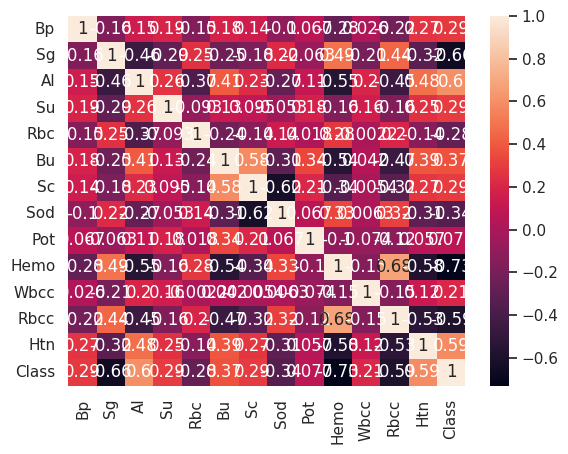

In [5]:
sns.heatmap(df.corr(),annot=True)

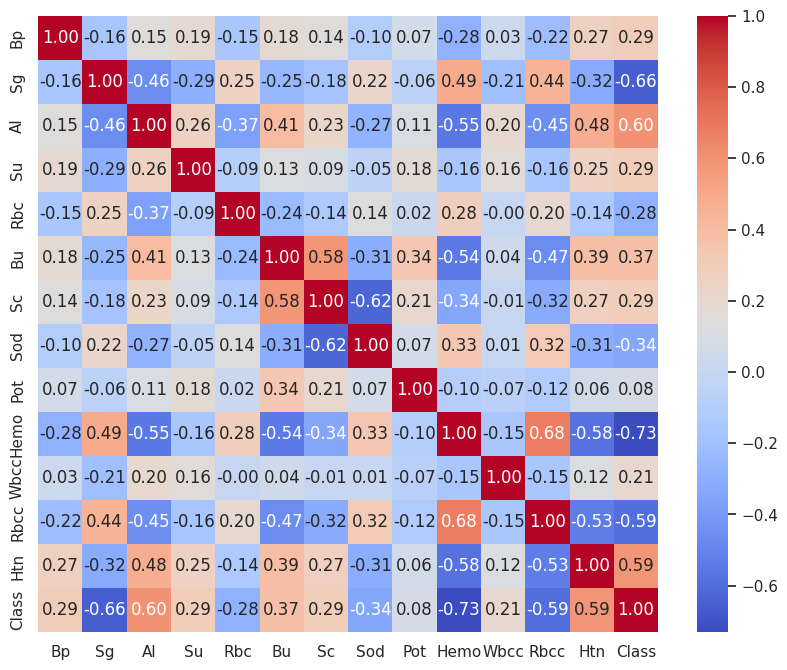

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.show()

In [7]:
df.columns

Index(['Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc',
       'Rbcc', 'Htn', 'Class'],
      dtype='object')

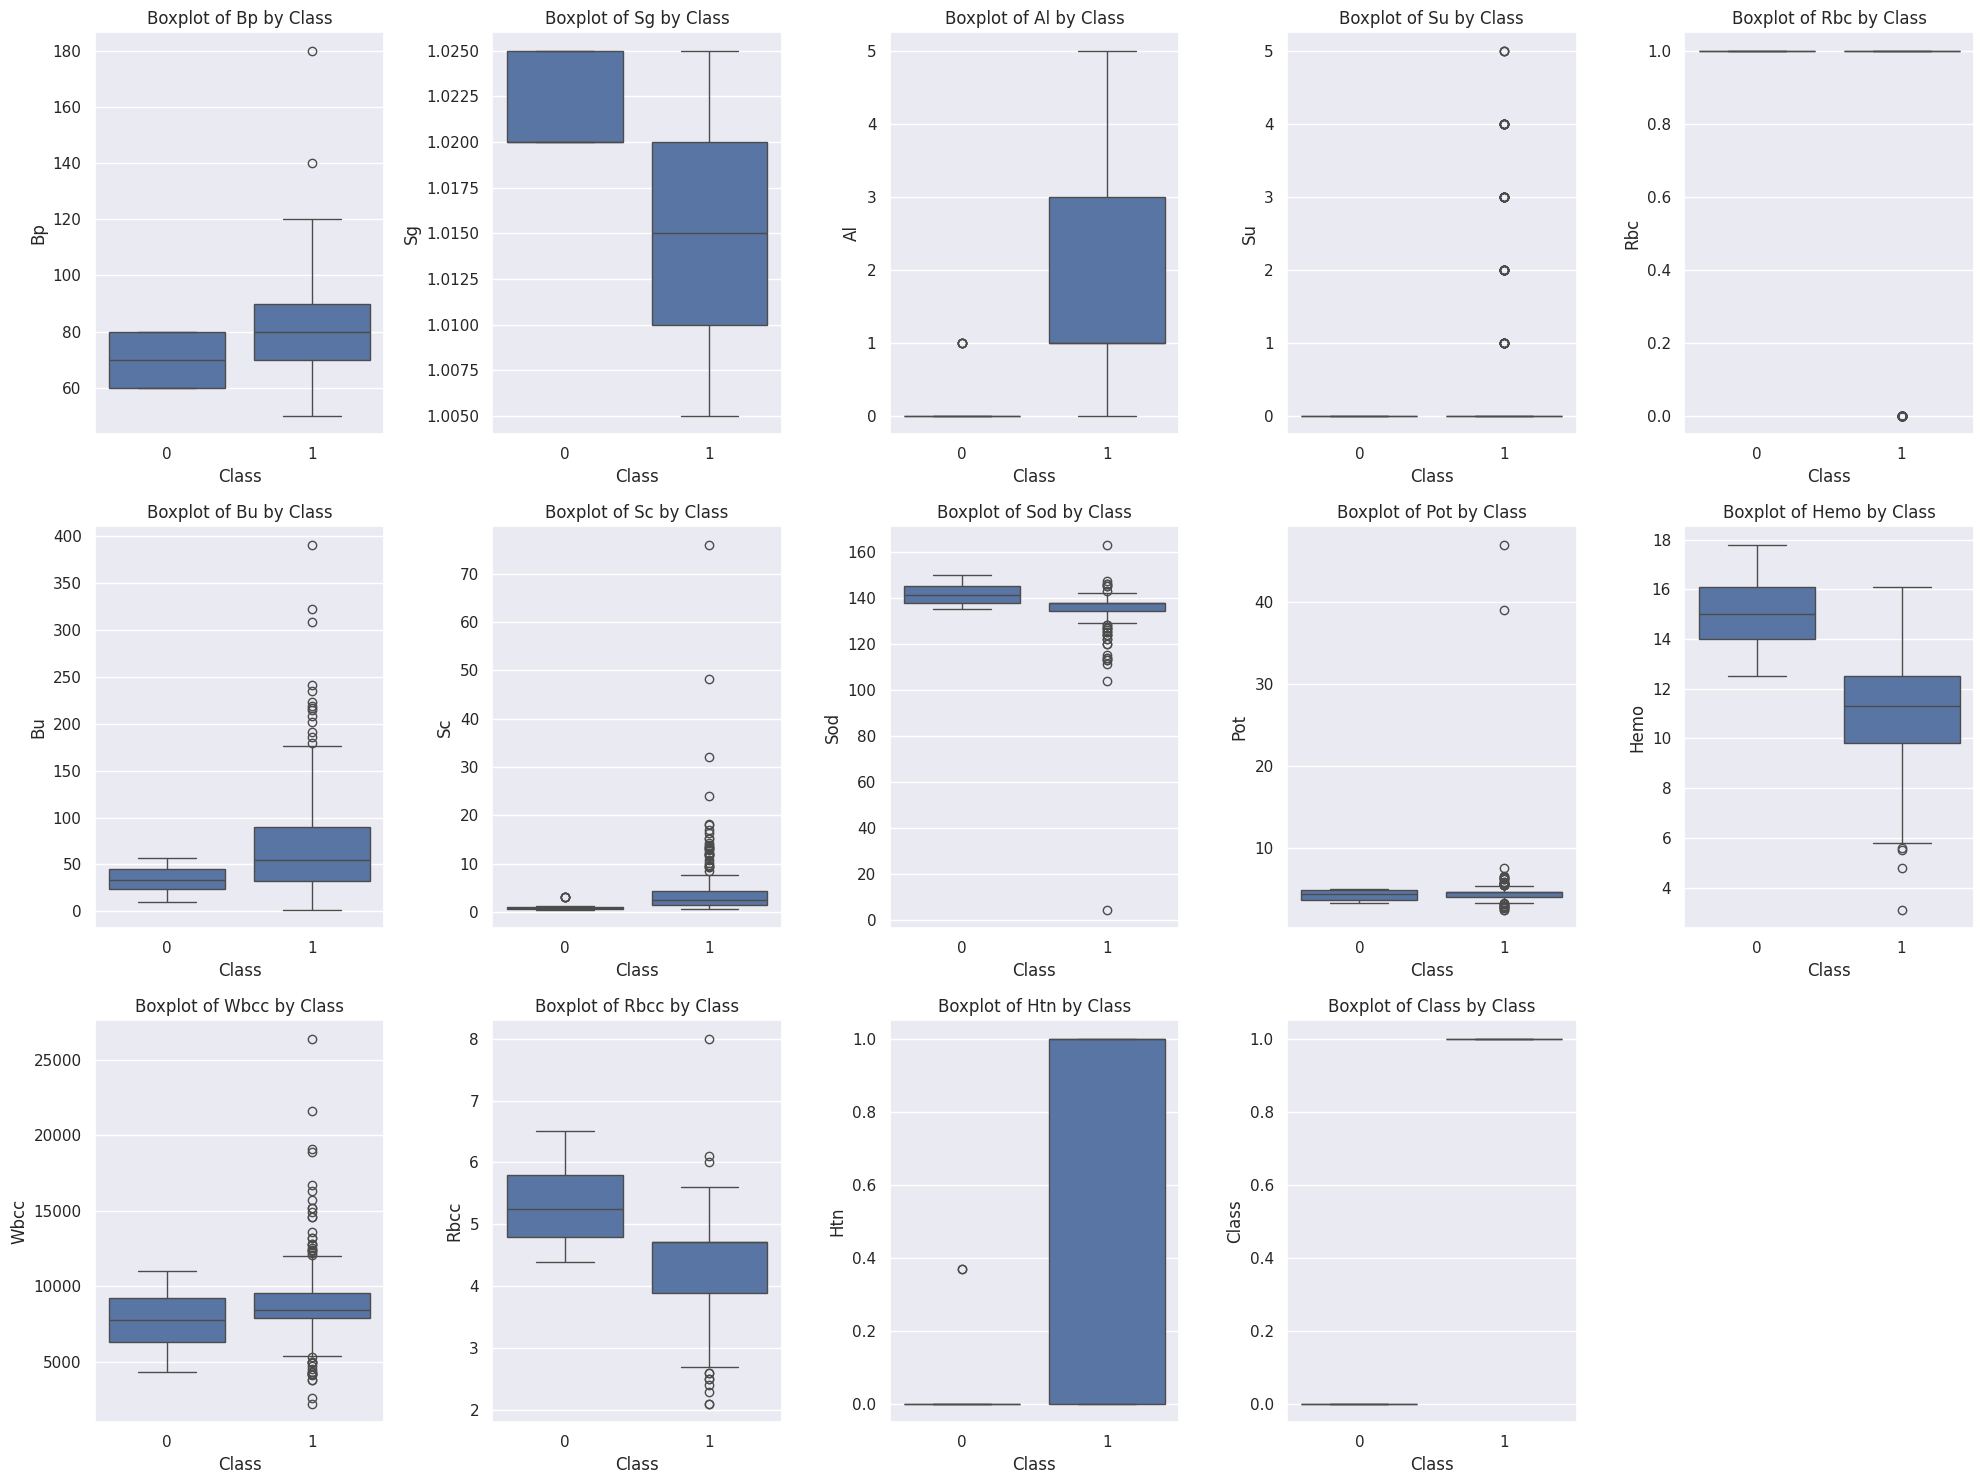

In [8]:
features=['Bp', 'Sg', 'Al', 'Su', 'Rbc', 'Bu', 'Sc', 'Sod', 'Pot', 'Hemo', 'Wbcc',
       'Rbcc', 'Htn', 'Class']
plt.figure(figsize=(20,15))
for i,feature in enumerate(features,1):
  plt.subplot(3,5,i) # Corrected from 3,3 to 3,5
  sns.boxplot(x='Class',y=feature,data=df)
  plt.title(f'Boxplot of {feature} by Class')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

In [10]:
x=df.drop('Class',axis=1)
y=df['Class']

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.transform(x_test)

In [12]:
lr=LogisticRegression()
lr.fit(x_train,y_train)


LogisticRegression()

In [13]:
y_pred=lr.predict(x_test)


In [14]:
print("accuracy of logistic regression")
accuracy_score(y_test,y_pred)

accuracy of logistic regression


1.0

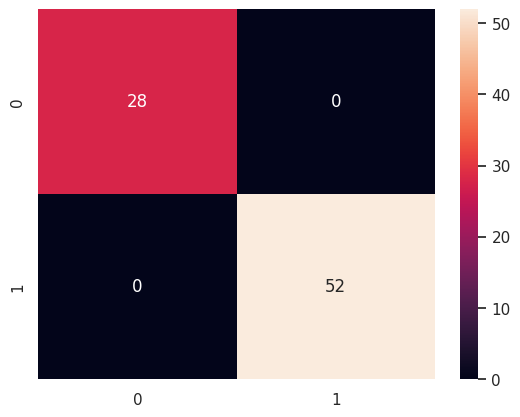

In [15]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()

In [ ]:
def predict_outcome():
  features_input=[]
  for col in x.columns:
    val=float(input(f"enter {col}:")) # Added a space for better readability
    features_input.append(val)

  features_array=np.array(features_input).reshape(1,-1)
  features_scaled=scalar.transform(features_array)
  prediction=lr.predict(features_scaled)
  if(prediction[0]==1):
    print("kidney decease")
  else:
    print("No kidney decease")

predict_outcome()